In [35]:
%pip install nbformat

You should consider upgrading via the '/Users/vsevolodpanteleev/Projects/dvfu/7-semester/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


# Импорты

In [ ]:
import os

import torch
from torchvision.transforms import v2
import PIL as pil
import ignite

import matplotlib.pyplot as plt

In [37]:
device = torch.device( "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.mps.is_available() else "cpu"))

device

device(type='mps')

In [38]:
class PedestrianDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, train: bool, transform=None,):
        self.data_dir = data_dir
        self.transform = transform

        images = []
        for dirpath, _, filenames in os.walk(data_dir):
            for filename in filenames:
                if filename.endswith((".tif")):
                    image_path = os.path.join(dirpath, filename)
                    if train and "train" in image_path.lower():
                        images.append(image_path)
                    elif not train and "test" in image_path.lower():
                        images.append(image_path)


        self.images = images

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, idx) -> pil.ImageFile:
        image_path = self.images[idx]
        image = pil.Image.open(image_path)
        transform = v2.Compose(
            [
                v2.Grayscale(),
                v2.PILToTensor(),
                v2.ToDtype(torch.float32),
                v2.Normalize(mean=(0.0,), std=(255.0,)),
            ]
        )
        image = transform(image)
        return image, image

In [39]:
train_ds = PedestrianDataset("UCSD_Anomaly_Dataset.v1p2/UCSDped1/Train/", train=True)
test_ds = PedestrianDataset("UCSD_Anomaly_Dataset.v1p2/UCSDped1/Test/", train=False)

In [ ]:
BATCH_SIZE = 64
train_loader = torch.utils.data.DataLoader(train_ds, BATCH_SIZE, shuffle=True)
# input_shape = next(iter(train_loader))[0].shape
# input_shape

torch.Size([64, 1, 158, 238])

In [41]:
class VAEModel(torch.nn.Module):
    def __init__(self, latent_dim=2):
        super(VAEModel, self).__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Conv2d(
                1, 16, kernel_size=5, stride=2, padding=2
            ),  # -> (16,79,119)
            torch.nn.ReLU(),
            torch.nn.Conv2d(
                16, 32, kernel_size=5, stride=2, padding=2
            ),  # -> (32,40,60)
            torch.nn.ReLU(),
            torch.nn.Conv2d(
                32, 64, kernel_size=5, stride=2, padding=2
            ),  # -> (64,20,30)
            torch.nn.ReLU(),
            torch.nn.Flatten(),
            torch.nn.Linear(64 * 20 * 30, 32),
            torch.nn.ReLU(),
        )

        self.mean_layer = torch.nn.Linear(32, latent_dim)
        self.logvar_layer = torch.nn.Linear(32, latent_dim)

        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 64 * 20 * 30),
            torch.nn.LeakyReLU(),
            torch.nn.Unflatten(1, (64, 20, 30)),
            torch.nn.ConvTranspose2d(
                64, 32, kernel_size=5, stride=2, padding=2, output_padding=0
            ),
            torch.nn.LeakyReLU(),
            torch.nn.ConvTranspose2d(
                32, 16, kernel_size=5, stride=2, padding=2, output_padding=1
            ),
            torch.nn.LeakyReLU(),
            torch.nn.ConvTranspose2d(
                16, 1, kernel_size=5, stride=2, padding=1, output_padding=1
            ),
            torch.nn.Sigmoid(),
        )

    def encode(self, x) :
        x = self.encoder(x)
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        return mean, logvar

    def __reparameterization(self, mean, logvar):
        epsilon = torch.randn_like(logvar)
        std = torch.exp(0.5 * logvar)
        z = mean + std * epsilon
        return z

    def __decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.__reparameterization(mean, logvar)
        x_hat = self.__decode(z)
        x_hat = x_hat.reshape(x.shape)
        return x_hat, mean, logvar


# print(torchinfo.summary(VAEModel().encoder, input_size=input_shape))

# torchinfo.summary(
#     VAEModel().decoder,
#     input_size=(
#         BATCH_SIZE,
#         6,
#     ),
# )

In [ ]:
def reproduction_loss_fn(y_pred, y):
    x_hat = y_pred[0]
    return torch.nn.functional.mse_loss(x_hat, y)


def kld_loss_fn(y_pred, y):
    mean = y_pred[1]
    logvar = y_pred[2]
    return -0.5 * torch.mean(1 + logvar - mean.square() - logvar.exp())


def loss_fn(y_pred, y):
    return  reproduction_loss_fn(y_pred, y) + kld_loss_fn(y_pred, y)


In [43]:
model = VAEModel().to(device)
model_path = os.path.join('models', 'vae.pth')
os.makedirs('models', exist_ok=True)

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    print(f"Loaded model from {model_path}, skipping training")

else:
    optimizer = torch.optim.Adam(model.parameters())
    trainer = ignite.engine.create_supervised_trainer(model, optimizer, loss_fn, device)
    
    ignite.handlers.tqdm_logger.ProgressBar().attach(trainer, metric_names="all")

    train_evaluator = ignite.engine.create_supervised_evaluator(
        model,
        metrics=dict(
            loss=ignite.metrics.Loss(loss_fn),
            reproduction_loss=ignite.metrics.Loss(reproduction_loss_fn),
            kld_loss=ignite.metrics.Loss(kld_loss_fn),
        ),
        device=device,
    )
    
    @trainer.on(ignite.engine.Events.ITERATION_COMPLETED(every=24))
    def log_training_loss(engine):
        print(
            f"Epoch[{engine.state.epoch}], Iter[{engine.state.iteration}] Loss: {engine.state.output}"
        )

    @trainer.on(ignite.engine.Events.EPOCH_COMPLETED(every=5))
    def log_training_results(trainer):
        train_evaluator.run(train_loader)
        metrics = train_evaluator.state.metrics
        print(
            f"Training Results - Epoch[{trainer.state.epoch}] "
            f"Avg loss: {metrics['loss']:.4f} "
            f"Avg reproduction_loss: {metrics['reproduction_loss']:.4f} "
            f"Avg kld_loss: {metrics['kld_loss']:.4f}"
        )

    trainer.run(train_loader, max_epochs=15)
    torch.save(model.state_dict(), model_path)
    print(f"Saved trained model to {model_path}")

/Users/vsevolodpanteleev/Projects/dvfu/7-semester/.venv/lib/python3.9/site-packages/ignite/handlers/tqdm_logger.py:127: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

Epoch [1/15]: [25/107]  23%|██▎        [00:02<00:09]

Epoch[1], Iter[24] Loss: 0.0404752716422081


Epoch [1/15]: [49/107]  46%|████▌      [00:05<00:07]

Epoch[1], Iter[48] Loss: 0.031112249940633774


Epoch [1/15]: [73/107]  68%|██████▊    [00:08<00:03]

...

Epoch [15/15]: [63/107]  59%|█████▉     [00:05<00:04]

Epoch[15], Iter[1560] Loss: 0.00515012675896287


Epoch [15/15]: [87/107]  81%|████████▏  [00:08<00:01]

Epoch[15], Iter[1584] Loss: 0.004965322092175484


Training Results - Epoch[15] Avg loss: 0.0048 Avg reproduction_loss: 0.0048 Avg kld_loss: 0.0260
Saved trained model to models/vae.pth


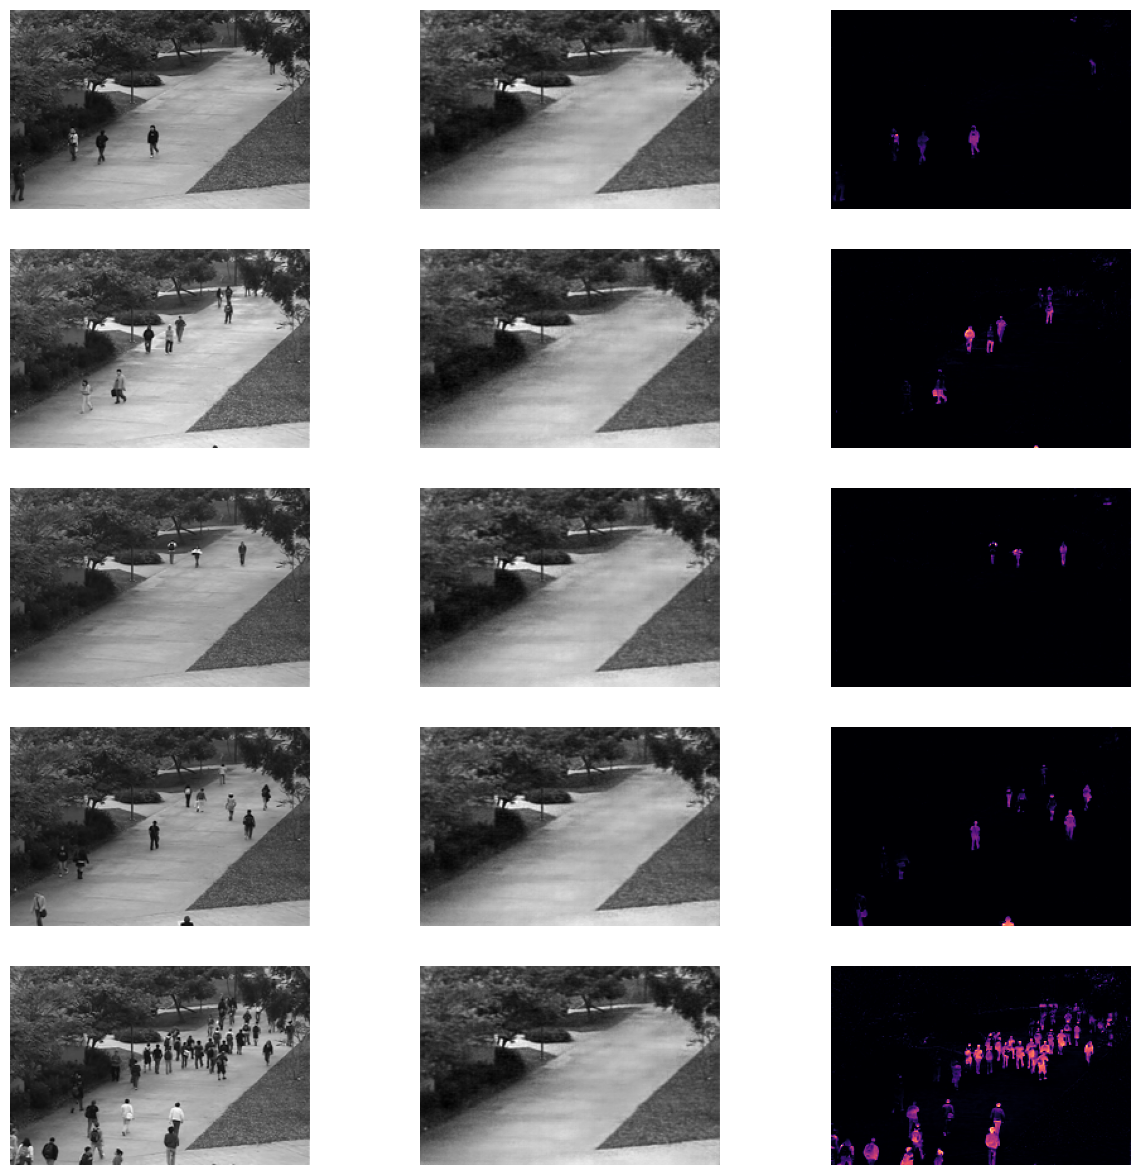

In [59]:
batch = next(iter(train_loader))[0].to(device)
model.eval()
img_hat_batch = model(batch)[0].cpu().detach()

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
for i in range(5):
    axes[i, 0].imshow(batch[i, 0].cpu(), cmap='gray')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(img_hat_batch[i, 0], cmap='gray')
    axes[i, 1].axis('off')
    axes[i, 2].imshow((img_hat_batch[i, 0] - batch[i, 0].cpu()).square(), cmap='magma')
    axes[i, 2].axis('off')